# Hackathon 1, statistics.

This project illustrates the statistics part of the course LEPL1109. In the first part of the project, you will study the mortality observed in Belgium. In the second part of the project, you try to predict the electricity consumption in Belgium using climate variables.

## Report content

•	Grades are granted to the members whose names are in the Jupyter notebook. If your name doesn’t appear on the top of the notebook, you’ll get a 0, even though you are in a group on Moodle.

•	The jupyter notebook must be compiled with printed results and next submitted via moodle. The absence of compiled results (or non-printed values) leads to a lower grade.

•	Do not comment your results directly into cells of code. Use instead a Markdown cell. 

•	"Dry" code or results not followed by a minimum of analysis / comments will be penalized.


## Report submission

•	Deadline, see moodle website. Submission after the deadline will not be accepted.

•	To submit your report, go to the section “Hackathon” on Moodle and the subsection “Remise Hackathon 1”. You can upload your work there. Once you are sure that it is your final version, click the button “Envoyer le devoir”. It is important that you don’t forget to click on this button ! 

•	Reports that have not been uploaded through Moodle will not be corrected.


## Names and Noma of participants:

Part. 1: Ivan Grégoire 37382400

Part. 2:

Part. 3:

Part. 4:

Part. 5:

Part. 6:

# Mortality and climate

In this section, we analyze the relationship between mortality, age groups, and seasons in Belgium using publicly available data from Statbel (see https://statbel.fgov.be/en/about-statbel/what-we-do/visualisations/mortality). The dataset contains the number of deaths recorded over time, disaggregated by age group and observed across different seasons. The objective is to study temporal patterns in mortality and assess the role of seasonal effects. 

## 1. Basic statistics

**1.1)** Load the dataset mortality_climate.csv. Convert the variables *season* and *CD_AGEGROUP* into a categorical variable. 

In [5]:
# Code here
import pandas as pd

data = pd.read_csv("mortality_climate.csv", sep=',')
#converti en array
datn = data.values
dates = datn[:,0]
SEASON = datn[:,1]
CD_AGEGROUP = datn[:,2]
MS_NUM_DEATH = datn[:,3]

**1.2)** Plot the evolution of the number of deaths (*MS_NUM_DEATH*) with respect to age group. What do you observe?

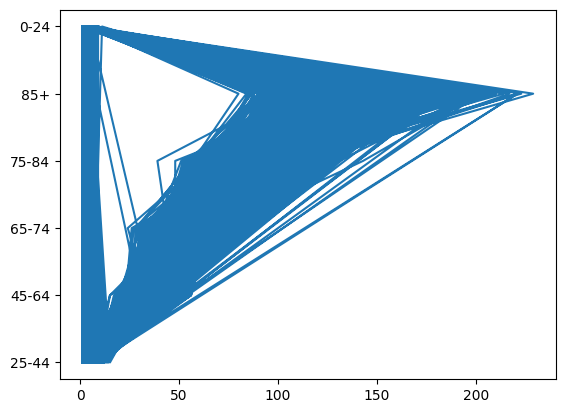

In [11]:
# Code here 
import matplotlib.pyplot as plt
plt.plot(MS_NUM_DEATH,CD_AGEGROUP)

Comments:

**1.3)** Do a scatter plot of the number of deaths (*MS_NUM_DEATH*) by age group.

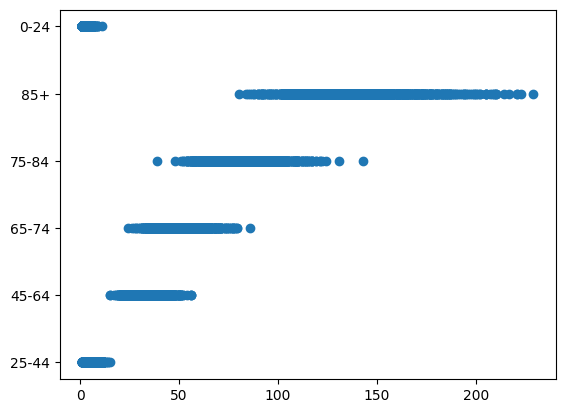

In [10]:
# Code here 
plt.scatter(MS_NUM_DEATH, CD_AGEGROUP)

Comments: 

## 2. Fit of distributions

**2.1)** For the 45–64 age group and the winter season only, fit both a Poisson and a Negative Binomial distribution to the variable 'MS_NUM_DEATH' using a maximum likelihood approach. Plot histograms overlaid with the fitted probability mass functions. Compare the log-likelihoods and select the most appropriate distribution.

In [1]:
# Code here


Comments: 

# 3. Regression

We now aim to assess whether seasonality has an impact on the number of deaths. We consider the following linear model:
$$\log(Y_i) = \beta_0 + \beta_1 X^S_{i1} + \cdots + \beta_3 X^S_{i3} + \beta_4 X^{age}_{i1} + \cdots + \beta_8 X^{age}_{i5}  + \varepsilon_i.$$

where $Y_i$ denotes the number of deaths, $X^S_{ij}$ are dummy variables representing the different seasons, $X^{age}_{ij}$ are dummy variables representing the different age groups, and $\varepsilon_i \sim N(0, \sigma^2)$. 

**3.1)** Why is it more appropriate to use a linear regression on $\log(Y)$ rather than directly on $Y$?

Comments:

**3.2)** Perform a linear regression of the number of deaths on the seasonal and group age covariates. Use the `OLS` function from the *statsmodels* package. Make sure to convert the variable *season* and *CD_AGEGROUP* into dummy variables before fitting the model.

Does seasonality have a significant impact on mortality? Is the mortality similar for each age group? 

In [2]:
# Code here


Comments: 

## 4. Hypothesis test 

We now investigate whether mortality decreases over time by comparing mortality in summer in 2022 and 2025. To this end, we aim to perform the following hypothesis test:

$$
H_0 : \mu_{2022} = \mu_{2025},
$$

$$
H_1 : \mu_{2022} \neq \mu_{2025}.
$$

**4.1)** Create two subsets of the original dataset corresponding to the years 2022 and 2025, respectively.

In [3]:
# Code here


**4.2)** For the 85+ age group, perform a Student’s t-test to compare mortality between 2022 and 2025 **in summer**. Check whether the assumptions required to apply this test are satisfied.

In [4]:
# Code here


Comments:

**4.3)** Explain what the Wilcoxon test is. Why could it be relevant in our setting?

Comments: 

**4.4)** For the 85+ age group, perform a Wilcoxon test to compare mortality between 2022 and 2025 **in summer**. What do you conclude?

In [8]:
# Code here


Comments:

**4.5)** Perform the Wilcoxon test but now for the 25–44 age group and the **summer**. What do you conclude in this case?

In [9]:
# Code here 


Comments: 

# Electricity Consumption and Climate

In this section, we aim to predict electricity consumption using past consumption values and climatic variables. We rely on data provided by ELIA (see https://opendata.elia.be/explore/dataset/ods003/information/?sort=datetime), which records total electricity consumption in Belgium at a 15-minute frequency, and meteorological data from the Royal Meteorological Institute (IRM) (see https://www.meteo.be/fr/services/donnees), which provides daily average temperature observations over Belgium.

The goal is to build a predictive model for electricity demand based on its recent history and weather conditions. From a practical perspective, such forecasting is highly relevant for energy providers and grid operators, as accurately anticipating electricity demand one week ahead helps optimize production planning, ensure grid stability, and reduce operational costs.

## 5. Forecasting 

The goal is to predict electricity consumption at time $t$ using its past values and climate features. Let $Y_t$ denote electricity consumption at time $t$. We consider the following regression model:

$$Y_t = \beta_0 + \beta_1 Y_{t-7Days} + \beta_2 \bar{T}_{t-7Days} + \beta_3 \bar{T}_{t-7Days}^2 + \varepsilon_t,$$

where $Y_{t-7Days}$ denotes electricity consumption observed 7 days earlier, $\bar{T}_{t-7Days}$ is the average temperature observed 7 days earlier$^1$, and $\varepsilon_t \sim \mathcal{N}(0,\sigma^2)$ is an error term.

$^1$ The average temperature is measured at a daily frequency; therefore, $\bar{T}_{t-7Days}$ is constant for all time points $t$ within the same day.

**5.1)** Load the dataset *electricity_climate.csv* and construct the dataset required to perform the regression.

**Warning:** the data are observed at 15-minute intervals.

To build the regression dataset, each row must contain:
- electricity consumption at time $t$: $Y_t$,
- electricity consumption at time $t - 7$ days: $Y_{t-7Days}$,
- temperature at time $t - 7$ days: $\bar{T}_{t-7Days}$,
- the squared temperature at time $t - 7$ days: $\bar{T}_{t-7Days}^2$.

In [10]:
# Code here 


**5.2)** Split the dataset into a training set (first 75%) and a test set (last 25%).  Use the `OLS` function from the *statsmodels* package to fit linear regression model using only $Y_{t-7Days}$ as explanatory variable.

Analyze the regression output, discuss the statistical significance and performance of the model.

In [11]:
# Code here 


Comments:

**5.3)** Repeat the regression by including the climate variables in the model.

Are the climate variables statistically significant in explaining electricity consumption 7 days ahead?

In [12]:
# Code here


Comments: 

**5.4)** Compute the MAE and RMSE on the test set for both models: with and without climate variables.

Does the inclusion of climate variables improve the predictive performance of the model?

In [13]:
# Code here 


Comments: 

**5.5)** For the model including climate variables, plot the predicted electricity consumption versus the true consumption on the test set. Then, produce a second plot focusing only on the first 7 days of the test set.

In [5]:
# Code here 


Comments: